# The ladder and the margins on a second public dataset: sixteen months on a campus

Notebook 20 repeats the ladder on the public urban measurements of Medellín, four links over six months in one regime. This notebook does the same on the long-term LoRaWAN metadata of the University of Virginia campus (Nikseresht, Sobral, Goodall and Campbell, BuildSys 2025, https://doi.org/10.1145/3736425.3771960; data https://doi.org/10.18130/V3/RFTICK, CC BY 4.0): ten sensors and three gateways, 9 February 2024 to 11 June 2025, one uplink every five minutes, 2,091,512 receptions over 30 sensor-gateway pairs. Six sensors sit indoors, in offices, a laboratory and a classroom, four outdoors at building entrances and in a corridor; gateway A is on the roof of a five-story building, gateway B on the roof of a one-story building 0.8 to 1.2 km away, gateway C indoors on the second floor of a two-story building. The files `lorawan_combined_dataset.parquet` and `deployment_weather.parquet` of the Dataverse record go into `Data_Files/uva_lorawan/`.

What the data allow, and what they do not:

* Every sensor transmits at spreading factor 7 throughout (1,633 packets of sensor09 in May 2025 excepted), on the eight 125 kHz channels of US915 sub-band 2, so there is no spreading-factor regime to condition on. What the data have instead is drift: the monthly mean RSSI of the links to gateway A moves by up to 18 dB over the year, in step across the sensors, and the 18 m indoor link 03C by 19 dB. The margins are therefore compared under drift, which is the case for the recency-weighted and the adaptive shifts of notebook 17.
* The transmit power is not recorded, so the path loss is known only up to a constant per link. Everything here works on the negative RSSI: the per-link mean, the anchor, the deviations and the margins do not need the constant, and the static model learns the level of each link from its distance and placement as it would from the path loss.
* A link is a sensor-gateway pair; the 22 pairs with at least 5,000 receptions are kept (the eight dropped have 24 to 4,248). Link 10C begins on 23 May 2025, inside the hold-out, so it is a link that no model has seen in training.
* The environmental inputs are the readings of the campus weather station (temperature, humidity, pressure, wind, rain) merged to each reception as the last reading within the hour; the station has gaps, the longest about two months, and 6 % of the receptions carry no SNR. Both stay missing and LightGBM handles them as missing values; the only requirement for a reception to count is a complete link history (rung H4).
* Same chronological split as notebook 00: the first 80 % of the receptions in time for training, five forward-chaining validation blocks inside it, the last 20 % (from 26 February 2025) as hold-out. Clock features in the local time zone (America/New_York). History features as in `history_features.build`; rungs as in notebook 13: H1 the link history, H4 adds the same-channel history, the clock and the spreading factor, H6 the SNR of earlier packets and the weather, H7 the link level, the distance and the indoor flags of sensor and gateway. One LightGBM per rung, tuned on rung H4 as in notebook 13.
* Rung H4 gets the margin six ways on rolling windows, as in notebook 17: a regression with one shift, with a shift per state (working hours x recent-spread tercile), a quantile model with one shift, with a recency-weighted shift (half-life 30 days), and with an adaptive shift. Then the unseen-sensor test of notebooks 13 and 20: fitted on the other sensors, tested on every link of the held-out sensor.

In [1]:
import json
import time
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from history_features import build, H1, H4, H5
from margin_tools import pinball, shift_pooled, shift_groups, shift_weighted, aci, spread_groups, day_codes, boot_stat, transitions, clustering_ratio

RANDOM_STATE = 42
TAU = 0.99
HALF_LIFE = 30          # days, recency-weighted shift, as in notebook 17

In [2]:
# The public files, as released: one row per reception of a packet by a gateway. Coordinates and placement from the dataset's README.
SENSORS = {"sensor01": (38.0328110, -78.5095524, 1), "sensor02": (38.0321764, -78.5107493, 0), "sensor03": (38.0321568, -78.5108207, 1), "sensor04": (38.0327080, -78.5097230, 0),
           "sensor05": (38.0333228, -78.5111476, 0), "sensor06": (38.0332850, -78.5111832, 1), "sensor07": (38.0328110, -78.5095524, 1), "sensor08": (38.0347279, -78.5135257, 0),
           "sensor09": (38.0346453, -78.5134932, 1), "sensor10": (38.0318946, -78.5102145, 1)}                      # latitude, longitude, indoor
GATEWAYS = {"gatewayA": (38.0317195, -78.5108640, 0), "gatewayB": (38.0365606, -78.5225695, 0), "gatewayC": (38.0322023, -78.5106216, 1)}

def distance_m(p, q):
    la1, lo1, la2, lo2 = np.radians([p[0], p[1], q[0], q[1]])
    h = np.sin((la2 - la1) / 2) ** 2 + np.cos(la1) * np.cos(la2) * np.sin((lo2 - lo1) / 2) ** 2
    return float(2 * 6371000 * np.arcsin(np.sqrt(h)))

raw = pd.read_parquet("Data_Files/uva_lorawan/lorawan_combined_dataset.parquet")
df = pd.DataFrame({"sensor": raw["Sensor Alias"], "gateway": raw["Gateway Alias"], "t": raw["Timestamp"], "PL": -raw["RSSI (dBm)"], "snr": raw["SNR (dB)"],
                   "SF": raw["Spreading Factor (-)"].astype(int), "frequency": raw["Frequency (Hz)"] / 1e6})
df["device_id"] = df["sensor"].str[-2:] + df["gateway"].str[-1]                                           # the link, e.g. 01A
df = df[df.groupby("device_id")["PL"].transform("size") >= 5000]
geometry = pd.DataFrame([{"sensor": s, "gateway": g, "distance": distance_m(SENSORS[s], GATEWAYS[g]), "sensor_indoor": SENSORS[s][2], "gateway_indoor": GATEWAYS[g][2]}
                         for s in SENSORS for g in GATEWAYS])
df = df.merge(geometry, on=["sensor", "gateway"]).sort_values("t").reset_index(drop=True)

w = pd.read_parquet("Data_Files/uva_lorawan/deployment_weather.parquet")
weather = pd.DataFrame({"t": w["Timestamp"], "temperature": (w["Temperature ( F )"] - 32) / 1.8, "humidity": w["Humidity ( RH )"], "pressure": w["Barometric Pressure ( INHG )"] * 33.8639,
                        "wind": w["Wind Speed ( MPH )"] * 0.44704, "rain": w["Accumulated Rain ( IN )"] * 25.4}).sort_values("t")
WEATHER = ["temperature", "humidity", "pressure", "wind", "rain"]
df = pd.merge_asof(df, weather, on="t", direction="backward", tolerance=pd.Timedelta("1h"))          # the last station reading within the hour; missing in the station's gaps

# The chronological split and the forward-chaining folds of notebook 00 (fold -1 = first training block, 0-4 = validation blocks, 9 = hold-out)
split = int(len(df) * 0.8)
fold = np.full(len(df), 9)
fold[:split] = -1
for k, (_, va) in enumerate(TimeSeriesSplit(n_splits=5).split(df.iloc[:split])):
    fold[va] = k
df["fold"] = fold
links = df.groupby("device_id").agg(receptions=("PL", "size"), first=("t", "min"), last=("t", "max"), distance_m=("distance", "first"), sensor_indoor=("sensor_indoor", "first"),
                                    gateway_indoor=("gateway_indoor", "first"), PL_mean=("PL", "mean"), PL_sd=("PL", "std"))
links["first"], links["last"] = links["first"].dt.date, links["last"].dt.date
display(links.round(1))
print(f"{len(df):,} receptions on {df['device_id'].nunique()} links; training {split:,} up to {df['t'].iloc[split - 1]:%Y-%m-%d %H:%M}, hold-out {len(df) - split:,} from "
      f"{df['t'].iloc[split]:%Y-%m-%d %H:%M}; weather missing for {df['temperature'].isna().mean():.1%} of the receptions, SNR for {df['snr'].isna().mean():.1%}")

,receptions,first,last,distance_m,sensor_indoor,gateway_indoor,PL_mean,PL_sd
device_id,,,,,,,,
01A,117049,2024-02-09,2025-06-11,167.1,1,0,93.4,9.5
01B,9443,2024-02-09,2025-06-11,1213.9,1,0,109.6,9.2
01C,95134,2024-02-09,2025-06-11,115.5,1,1,108.6,2.9
02A,115072,2024-02-09,2025-06-11,51.8,0,0,99.9,9.5
02C,150752,2024-02-09,2025-06-11,11.5,0,1,79.1,6.5
03A,118105,2024-02-09,2025-05-19,48.8,1,0,90.7,9.2
03B,11690,2024-02-09,2025-05-23,1139.6,1,0,112.6,6.8
03C,123429,2024-02-09,2025-05-23,18.2,1,1,61.7,6.2
04A,117002,2024-02-09,2025-06-11,148.6,0,0,94.8,9.9


2,084,086 receptions on 22 links; training 1,667,268 up to 2025-02-26 20:10, hold-out 416,818 from 2025-02-26 20:10; weather missing for 11.8% of the receptions, SNR for 6.0%


In [3]:
# History features and rungs; the weather station takes the place of the room sensors
d = build(df, tz="America/New_York").sort_values("t").reset_index(drop=True)
fold = d["fold"].to_numpy()
rungs = {"H1": H1, "H4": H4, "H6": H5 + WEATHER, "H7": H5 + WEATHER + ["a", "distance", "sensor_indoor", "gateway_indoor"]}
static = ["distance", "sensor_indoor", "gateway_indoor", "frequency"] + WEATHER
ok = (d["y"].notna() & d[rungs["H4"]].notna().all(axis=1)).to_numpy()      # a complete link history; missing weather and missing earlier SNR stay missing
y, a, PL = d["y"].to_numpy(), d["a"].to_numpy(), d["PL"].to_numpy()
link, sensor, gateway = d["device_id"].to_numpy(), d["sensor"].to_numpy(), d["gateway"].to_numpy()
work, s20 = d["work"].to_numpy().astype(int), d["s20"].to_numpy()
day = day_codes(d["t"])
val, ev = ok & (fold >= 0) & (fold < 9), ok & (fold == 9)
X_all = d[sorted(set(sum(rungs.values(), []) + static + ["snr"]))]
print(f"receptions with an anchor and a complete history: {ok.sum():,} of {len(d):,}; validation {val.sum():,}; hold-out {ev.sum():,}")

receptions with an anchor and a complete history: 2,061,943 of 2,084,086; validation 1,376,868; hold-out 413,048


In [4]:
# One light search on rung H4, every tenth row, as in notebook 13; the same settings for every rung
sub = np.flatnonzero(ok & (fold < 9))[::10]
cv_sub = [(np.flatnonzero(fold[sub] < k), np.flatnonzero(fold[sub] == k)) for k in range(5)]
space = {"num_leaves": Integer(15, 255), "learning_rate": Real(0.01, 0.2, prior="log-uniform"), "n_estimators": Integer(200, 1500), "min_child_samples": Integer(20, 1000),
         "subsample": Real(0.6, 1.0), "colsample_bytree": Real(0.5, 1.0), "reg_lambda": Real(0.1, 30, prior="log-uniform")}
t0 = time.time()
bs = BayesSearchCV(lgb.LGBMRegressor(subsample_freq=1, random_state=RANDOM_STATE, n_jobs=4, verbose=-1), space, n_iter=20, cv=cv_sub, scoring="neg_root_mean_squared_error",
                   n_jobs=8, n_points=2, random_state=RANDOM_STATE, refit=False)
bs.fit(X_all[rungs["H4"]].to_numpy()[sub], y[sub])
best = dict(bs.best_params_)
json.dump(best, open("CV_Results/uva_best_params.json", "w"), indent=1, default=float)
print(f"search RMSE {-bs.best_score_:.3f} dB after {time.time() - t0:.0f} s: {best}")
params = dict(subsample_freq=1, random_state=RANDOM_STATE, n_jobs=8, verbose=-1, **best)

def oof_and_test(make, cols, target):
    X = X_all[cols].to_numpy()
    p = np.full(len(d), np.nan)
    for k in range(5):
        tr, va = ok & (fold < k), ok & (fold == k)
        p[va] = make().fit(X[tr], target[tr]).predict(X[va])
    p[ev] = make().fit(X[ok & (fold < 9)], target[ok & (fold < 9)]).predict(X[ev])
    return p

search RMSE 2.680 dB after 74 s: {'colsample_bytree': 0.8697521170952103, 'learning_rate': 0.024895216086676577, 'min_child_samples': 655, 'n_estimators': 915, 'num_leaves': 45, 'reg_lambda': 0.2761439033398466, 'subsample': 0.8528382512601542}


In [5]:
# The ladder: predicted level for every rung, and the references that need no model
pred = {}
t0 = time.time()
mean = np.full(len(d), np.nan)                                       # the mean of each link over the earlier training packets
for k in list(range(5)) + [9]:
    earlier = d[ok & (fold < k)] if k < 9 else d[ok & (fold < 9)]
    mean[fold == k] = d.loc[fold == k, "device_id"].map(earlier.groupby("device_id")["PL"].mean())
pred["per-link mean"] = mean
pred["previous hour mean"] = a
pred["static inputs without the weather"] = oof_and_test(lambda: lgb.LGBMRegressor(**params), ["distance", "sensor_indoor", "gateway_indoor", "frequency"], PL)
pred["static inputs"] = oof_and_test(lambda: lgb.LGBMRegressor(**params), static, PL)
pred["static inputs + SNR of the same packet"] = oof_and_test(lambda: lgb.LGBMRegressor(**params), static + ["snr"], PL)
for name, cols in rungs.items():
    pred[f"rung {name}"] = a + oof_and_test(lambda: lgb.LGBMRegressor(**params), cols, y)
print(f"{time.time() - t0:.0f} s")

te = np.flatnonzero(ev & np.isfinite(mean))                          # link 10C has no training packets and so no per-link mean; it is tested below as a link never seen
dd = pd.factorize(day[te])[0]
rmse = lambda e: float(np.sqrt(np.mean(np.square(e))))
rows = []
for name, p in pred.items():
    e = PL - p
    c = shift_pooled(e[val & np.isfinite(e)], TAU)
    r = boot_stat(dd, np.column_stack([e[te] ** 2, np.ones(len(te))]), lambda T: np.sqrt(T[:, 0] / T[:, 1]))
    rows.append({"inputs": name, "hold-out RMSE": r[0], "lo": r[1], "hi": r[2], "validation RMSE": rmse(e[val & np.isfinite(e)]), "99 % shift dB": c, "coverage": float((e[te] <= c).mean()),
                 "pinball x 1000": 1000 * pinball(e[te], c, TAU).mean()})
ladder = pd.DataFrame(rows).set_index("inputs")
ladder.to_csv("CV_Results/uva_ladder.csv")
display(ladder.round(3))
print("99 % quantile of the out-of-fold error by validation block, static inputs without / with the weather:",
      [(k, round(float(np.quantile((PL - pred["static inputs without the weather"])[ok & (fold == k)], 0.99)), 1), round(float(np.quantile((PL - pred["static inputs"])[ok & (fold == k)], 0.99)), 1))
       for k in range(5)])

345 s


,hold-out RMSE,lo,hi,validation RMSE,99 % shift dB,coverage,pinball x 1000
inputs,,,,,,,
per-link mean,6.940,6.640,7.248,8.802,14.464,0.973,216.781
previous hour mean,3.328,3.252,3.407,3.309,10.000,0.991,121.903
static inputs without the weather,6.806,6.502,7.123,8.875,14.689,0.979,199.076
static inputs,5.825,5.431,6.247,7.436,24.095,0.998,254.143
static inputs + SNR of the same packet,5.194,4.850,5.603,7.036,23.065,1.000,237.213
rung H1,3.171,3.109,3.225,3.118,9.395,0.990,115.954
rung H4,2.771,2.713,2.825,2.627,7.707,0.988,104.466
rung H6,2.734,2.676,2.787,2.601,7.799,0.989,101.700
rung H7,2.725,2.667,2.778,2.603,7.838,0.990,101.538


99 % quantile of the out-of-fold error by validation block, static inputs without / with the weather: [(0, 14.5, 28.5), (1, 15.8, 22.2), (2, 14.5, 13.3), (3, 14.6, 12.9), (4, 13.3, 13.0)]


In [6]:
# Rung H4 with the margin built six ways on rolling windows, as in notebook 17: a regression with one shift or a shift per state (working hours x recent-spread tercile),
# a quantile model with one shift, a recency-weighted shift or an adaptive shift
X4 = rungs["H4"]
reg = pred["rung H4"] - a
q = oof_and_test(lambda: lgb.LGBMRegressor(objective="quantile", alpha=TAU, **params), X4, y)
windows = [1, 2, 3, 4, 9]
margin, cuts, rows_of = {}, {}, {}
for w in windows:
    t_ = np.flatnonzero(ok & (fold == w))
    cal = np.flatnonzero(ok & (fold >= 0) & (fold < w))
    cut = np.quantile(s20[cal], [1 / 3, 2 / 3])
    rows_of[w], cuts[w] = t_, cut
    state = lambda i: work[i] * 3 + spread_groups(s20[i], cut)
    age = (d["t"].iloc[t_].min() - d["t"].iloc[cal]).dt.total_seconds().to_numpy() / 86400
    for kind, b in (("reg", reg), ("q", q)):
        score = y[cal] - b[cal]
        margin[(w, f"{kind} pooled")] = b[t_] + shift_pooled(score, TAU)
        if kind == "reg":
            margin[(w, "reg state table")] = b[t_] + shift_groups(score, state(cal), state(t_), TAU)
        else:
            margin[(w, "q recency")] = b[t_] + shift_weighted(score, age, TAU, HALF_LIFE)
            m = np.empty(len(t_))
            for l in np.unique(link[t_]):
                i = np.flatnonzero(link[t_] == l)
                m[i] = aci(b[t_][i], y[t_][i], score, TAU, (1 - TAU) / 20)
            margin[(w, "q ACI")] = m
methods = ["reg pooled", "reg state table", "q pooled", "q recency", "q ACI"]

rows = []
for w in windows:
    t_ = rows_of[w]
    for method in methods:
        m = margin[(w, method)]
        miss = y[t_] > m
        states = {"all": np.ones(len(t_), bool), "other hours": work[t_] == 0, "working hours": work[t_] == 1, "calm spread": spread_groups(s20[t_], cuts[w]) == 0,
                  "volatile spread": spread_groups(s20[t_], cuts[w]) == 2}
        states.update({f"gateway {g[-1]}": gateway[t_] == g for g in np.unique(gateway[t_])})
        states.update({str(k): link[t_] == k for k in np.unique(link[t_]) if (link[t_] == k).sum() >= 1000})
        for g, sel in states.items():
            rows.append(dict(window=w, method=method, state=g, n=int(sel.sum()), coverage=1 - miss[sel].mean(), margin=m[sel].mean(), pinball=1000 * pinball(y[t_][sel], m[sel], TAU).mean()))
margins = pd.DataFrame(rows)
margins.to_csv("CV_Results/uva_margins.csv", index=False)
print("coverage at the 99 % target by window and method, all packets")
display(margins[margins.state == "all"].pivot(index="method", columns="window", values="coverage").loc[methods].round(4))
print("hold-out coverage by state")
display(margins[margins.window == 9].pivot(index="state", columns="method", values="coverage")[methods].round(4))
print("hold-out mean margin above the anchor (dB) and pinball loss x 1000, all packets")
display(margins[(margins.window == 9) & (margins.state == "all")].set_index("method")[["margin", "pinball"]].loc[methods].round(3))

coverage at the 99 % target by window and method, all packets


window,1,2,3,4,9
method,,,,,
reg pooled,0.9879,0.9932,0.9918,0.9884,0.9879
reg state table,0.9894,0.9920,0.9912,0.9908,0.9896
q pooled,0.9912,0.9932,0.9919,0.9916,0.9901
q recency,0.9912,0.9927,0.9903,0.9905,0.9888
q ACI,0.9906,0.9905,0.9904,0.9903,0.9902


hold-out coverage by state


method,reg pooled,reg state table,q pooled,q recency,q ACI
state,,,,,
01A,0.9783,0.9864,0.9892,0.9886,0.9896
01B,0.9983,0.9920,0.9920,0.9885,0.9914
01C,1.0000,0.9946,0.9936,0.9924,0.9904
02A,0.9870,0.9913,0.9928,0.9923,0.9905
02C,0.9978,0.9954,0.9924,0.9903,0.9899
03A,0.9763,0.9828,0.9856,0.9847,0.9900
03C,0.9996,0.9981,0.9969,0.9959,0.9902
04A,0.9580,0.9802,0.9819,0.9810,0.9897
04C,0.9997,0.9933,0.9901,0.9879,0.9906


hold-out mean margin above the anchor (dB) and pinball loss x 1000, all packets


,margin,pinball
method,,
reg pooled,7.719,104.127
reg state table,6.278,80.138
q pooled,5.833,73.042
q recency,5.710,73.113
q ACI,5.980,71.504


In [7]:
# Independence of the misses on the hold-out (successive receptions of a link at most ten minutes apart, two uplink intervals), and the differences between the margins
t_ = rows_of[9]
dd = pd.factorize(day[t_])[0]
rows = []
for method in methods:
    T = transitions(d["t"].iloc[t_], link[t_], y[t_] > margin[(9, method)], max_gap=600)
    r = boot_stat(dd, T, clustering_ratio)
    rows.append(dict(method=method, miss_clustering=r[0], lo=r[1], hi=r[2]))
independence = pd.DataFrame(rows).set_index("method")
independence.to_csv("CV_Results/uva_independence.csv")
display(independence.round(2))
rows = []
for m1, m2 in [("q pooled", "reg pooled"), ("q pooled", "reg state table"), ("q recency", "q pooled"), ("q ACI", "q pooled")]:
    diff = pinball(y[t_], margin[(9, m1)], TAU) - pinball(y[t_], margin[(9, m2)], TAU)
    r = boot_stat(dd, np.column_stack([diff, np.ones(len(t_))]), lambda T: 1000 * T[:, 0] / T[:, 1])
    rows.append(dict(a=m1, b=m2, pinball_difference=r[0], lo=r[1], hi=r[2]))
contrasts = pd.DataFrame(rows)
contrasts.to_csv("CV_Results/uva_margin_contrasts.csv", index=False)
display(contrasts.round(3))

,miss_clustering,lo,hi
method,,,
reg pooled,4.81,4.03,5.84
reg state table,3.55,2.85,4.36
q pooled,1.97,1.51,2.49
q recency,1.79,1.39,2.23
q ACI,1.99,1.50,2.60


,a,b,pinball_difference,lo,hi
0,q pooled,reg pooled,-31.085,-32.270,-29.973
1,q pooled,reg state table,-7.096,-7.532,-6.651
2,q recency,q pooled,0.070,-0.001,0.145
3,q ACI,q pooled,-1.539,-1.921,-1.189


In [8]:
# A sensor the model has never seen, as in notebooks 13 and 20: fit on the links of the other sensors with validation folds 0 to 3, calibrate the 99 % margin on their
# fold 4, test on every link of the held-out sensor in the hold-out, with the margin kept as calibrated or adapted to the link's own misses as it goes
rows = []
for name, cols, target in (("static inputs", static, PL), ("rung H1", rungs["H1"], y), ("rung H4", rungs["H4"], y)):
    X = X_all[cols].to_numpy()
    for s in sorted(np.unique(sensor)):
        other = sensor != s
        fit_m, cal_m = ok & other & (fold >= 0) & (fold < 4), ok & other & (fold == 4)
        m = lgb.LGBMRegressor(**params).fit(X[fit_m], target[fit_m])
        e_cal = target[cal_m] - m.predict(X[cal_m])
        c = shift_pooled(e_cal, TAU)
        for l in np.unique(link[ev & (sensor == s)]):
            test_m = ev & (link == l)
            b = m.predict(X[test_m])
            e_test = target[test_m] - b
            adaptive = aci(b, target[test_m], e_cal, TAU, (1 - TAU) / 20)
            rows.append({"inputs": name, "link": l, "hold-out packets": int(test_m.sum()), "RMSE unseen": rmse(e_test), "bias unseen": float(e_test.mean()),
                         "RMSE with the sensor in training": rmse((PL - pred[name])[test_m]) if l != "10C" else np.nan, "99 % shift from the other sensors": c,
                         "coverage": float((e_test <= c).mean()), "adaptive margin": float((adaptive - b).mean()), "adaptive coverage": float((target[test_m] <= adaptive).mean())})
unseen = pd.DataFrame(rows).set_index(["inputs", "link"])
unseen.to_csv("CV_Results/uva_unseen_sensor.csv")
pd.set_option("display.max_rows", 100)
display(unseen.round(3))

hold-out packets  RMSE unseen  bias unseen  \
inputs        link                                               
static inputs 01A              22845        7.930        4.621   
              01B               1746        3.711        0.444   
              01C              22693        3.710        2.215   
              02A              23329        6.492        3.791   
              02C              34502       16.373       14.773   
              03A              18429        9.049       -7.090   
              03B                 64        7.464       -1.456   
              03C              23883       24.511      -24.095   
              04A              22431       10.986       -8.826   
              04C              26894        3.272       -1.097   
              05A              24996        9.213       -7.316   
              05C              27101        3.854       -2.138   
              06A              25372        6.541       -2.972   
              06C               9974        3.044        1.255   
              07A              22525        6.471       -0.689   
              07B               1747        3.885       -0.686   
              07C              27361        4.250       -2.819   
              08A              22544        6.015       -1.252   
              08B              15287        4.316       -1.705   
              09A              23543        6.244       -0.089   
              09B              10597        4.770        2.243   
              10C               5185        3.511        0.139   
rung H1       01A              22845        4.105        0.043   
              01B               1746        2.172        0.021   
              01C              22693        1.763        0.001   
              02A              23329        4.042        0.002   
              02C              34502        1.433        0.028   
              03A              18429        3.914       -0.034   
              03B                 64        2.126       -0.232   
              03C              23883        0.916        0.017   
              04A              22431        4.974        0.021   
              04C              26894        2.265        0.008   
              05A              24996        3.485        0.019   
              05C              27101        1.516        0.018   
              06A              25372        2.032        0.008   
              06C               9974        1.140        0.003   
              07A              22525        4.945        0.100   
              07B               1747        2.210        0.079   
              07C              27361        1.755       -0.000   
              08A              22544        4.494       -0.016   
              08B              15287        2.511       -0.026   
              09A              23543        4.470       -0.001   
              09B              10597        2.373       -0.026   
              10C               5185        2.227        0.032   
rung H4       01A              22845        3.673       -0.031   
              01B               1746        2.149       -0.052   
              01C              22693        1.593       -0.012   
              02A              23329        3.386       -0.030   
              02C              34502        1.153        0.044   
              03A              18429        3.544       -0.054   
              03B                 64        2.146       -0.230   
              03C              23883        0.692        0.018   
              04A              22431        4.321       -0.041   
              04C              26894        1.946        0.015   
              05A              24996        2.545        0.006   
              05C              27101        1.375        0.013   
              06A              25372        1.729       -0.026   
              06C               9974        1.093       -0.015   
              07A              22525        3.934        0.0

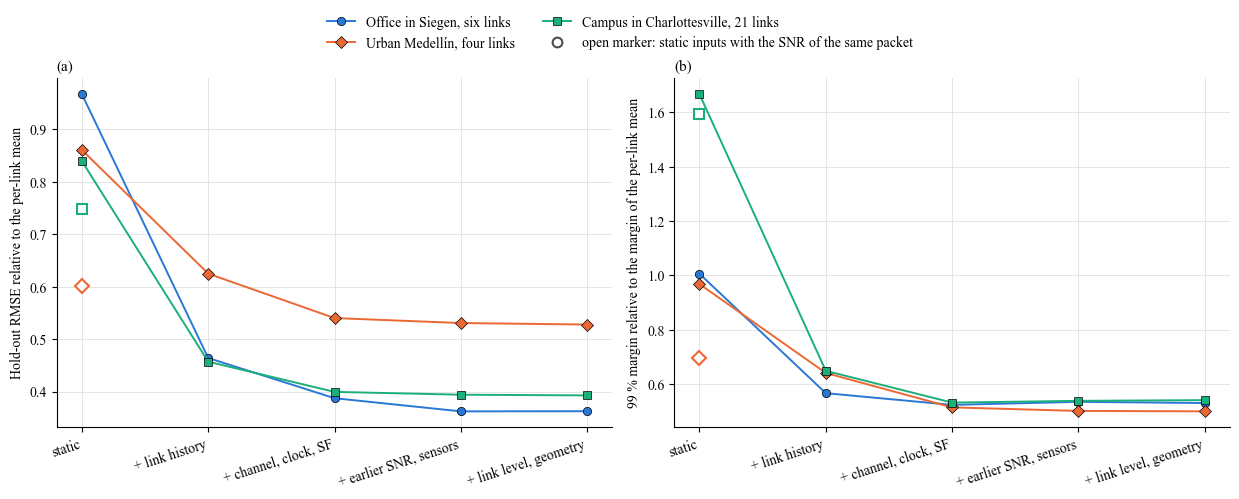

In [9]:
# Figure: the ladder on the three datasets, relative to the per-link mean (its RMSE and its 99 % margin), with the leaky variants
siegen = pd.read_csv("CV_Results/information_by_family.csv", index_col=[0, 1]).loc["LGBM"]
mean_siegen = pd.read_csv("CV_Results/history_benchmark.csv", index_col=[0, 1]).loc[("link mean", "-")]
medellin = pd.read_csv("CV_Results/medellin_ladder.csv", index_col=0)
labels = ["static", "+ link history", "+ channel, clock, SF", "+ earlier SNR, sensors", "+ link level, geometry"]
names = ["static inputs", "rung H1", "rung H4", "rung H6", "rung H7"]
curves = {"Office in Siegen, six links": ([siegen.loc[r, "hold-out RMSE"] / mean_siegen["hold-out RMSE"] for r in ("static", "H1", "H4", "H6", "H7")],
                                          [siegen.loc[r, "margin 0.99"] / mean_siegen["margin 0.99"] for r in ("static", "H1", "H4", "H6", "H7")], None, "#2a78d6", "o"),
          "Urban Medellín, four links": ([medellin.loc[n, "hold-out RMSE"] / medellin.loc["per-link mean", "hold-out RMSE"] for n in names],
                                         [medellin.loc[n, "99 % shift dB"] / medellin.loc["per-link mean", "99 % shift dB"] for n in names], medellin, "#eb6834", "D"),
          f"Campus in Charlottesville, {len(np.unique(link[te]))} links": ([ladder.loc[n, "hold-out RMSE"] / ladder.loc["per-link mean", "hold-out RMSE"] for n in names],
                                                  [ladder.loc[n, "99 % shift dB"] / ladder.loc["per-link mean", "99 % shift dB"] for n in names], ladder, "#1baf7a", "s")}
plt.rcParams.update({"font.family": "serif", "font.serif": ["Times New Roman", "DejaVu Serif"], "font.size": 10})
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.6))
for name, (r_, m_, table, color, marker) in curves.items():
    ax[0].plot(range(5), r_, marker=marker, ls="-", color=color, ms=6, mec="black", mew=0.5, lw=1.4, label=name)
    ax[1].plot(range(5), m_, marker=marker, ls="-", color=color, ms=6, mec="black", mew=0.5, lw=1.4)
    if table is not None:                                       # the static inputs with the SNR of the same packet, the leaky variant
        leaky = table.loc["static inputs + SNR of the same packet"]
        ax[0].plot([0], [leaky["hold-out RMSE"] / table.loc["per-link mean", "hold-out RMSE"]], marker=marker, ls="none", color="white", ms=7, mec=color, mew=1.5)
        ax[1].plot([0], [leaky["99 % shift dB"] / table.loc["per-link mean", "99 % shift dB"]], marker=marker, ls="none", color="white", ms=7, mec=color, mew=1.5)
ax[0].plot([], [], marker="o", ls="none", color="white", mec="0.3", mew=1.5, ms=7, label="open marker: static inputs with the SNR of the same packet")
for a_, ylab, tag in ((ax[0], "Hold-out RMSE relative to the per-link mean", "(a)"), (ax[1], "99 % margin relative to the margin of the per-link mean", "(b)")):
    a_.set_xticks(range(5), labels, rotation=18, ha="right")
    a_.set_ylabel(ylab)
    a_.set_title(tag, loc="left", fontsize=11)
    a_.grid(color="0.88", lw=0.6)
    a_.set_axisbelow(True)
    for sp in ("top", "right"):
        a_.spines[sp].set_visible(False)
fig.legend(*ax[0].get_legend_handles_labels(), loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.09))
fig.tight_layout()
fig.savefig("Figures/ladder_three_datasets.png", dpi=300, bbox_inches="tight")
plt.show()

**Reading of the results.**

* **The ladder replicates a third time, under drift.** The hold-out RMSE falls from 6.94 dB for the per-link mean to 3.33 for the previous-hour mean, 3.17 with the link's history, 2.77 with the same-channel history, the clock and the spreading factor, and 2.73 and 2.72 with the earlier SNR, the weather, the link level and the geometry. The 99 % margin falls from 14.5 dB for the per-link mean to 9.4, 7.7, 7.8 and 7.8 dB: 53 % of the per-link mean's margin from rung H4 on, against 52 % in the office and 52 % in Medellín. The RMSE at rung H4 is 40 % of the per-link mean's, 39 % in the office, 54 % in Medellín.
* **A fixed level does not hold under drift.** The per-link mean's margin, calibrated on the validation year, covers 97.3 % of the hold-out; the previous-hour mean and every history rung cover 98.8 to 99.1 %.
* **The weather carries the season, but only once the training data span it.** The static model with the weather reaches 5.82 dB on the hold-out, against 6.81 dB without it and 6.94 for the per-link mean: the level of the links to the rooftop gateway moves with the season and the station records that. Its 99 % margin, 24.1 dB, comes from the first two validation blocks, where weather terms fitted on two to five months were applied to the months that followed (99 % quantiles of 28 and 22 dB, against 13 dB from the third block on); without the weather the static model has the per-link mean's tail, 14.7 dB. The office showed nothing of the kind over one year on one floor.
* **The SNR of the same packet** lowers the static RMSE from 5.82 to 5.19 dB and does not reach the link's history (3.17 dB). Leakage, as in Medellín.
* **Margins under drift.** The regression with one shift covers 98.8 % of the hold-out but 97.7 % on the links to gateway A, 96.9 % in the volatile third of the packets and 95.8 % on the worst link (04A), while the links to the indoor gateway are covered 99.9 to 100 %; in the validation windows its worst link is at 95.3 %. A shift per state (working hours x recent spread) lowers the pinball loss by 23 % (104 to 80 per thousand), the quantile model with one shift by a further 9 % (73.0; -7.1 [-7.5, -6.7] per thousand against the state table), and the adaptive shift by 2 % more (71.5; -1.5 [-1.9, -1.2]) while bringing every link to 99.0 to 99.3 % and the worst link of a validation window to 98.9 %. The recency-weighted shift changes nothing (+0.07 [-0.00, +0.15]): the quantile model's inputs already follow the drift, the calibration scores do not need to. After a miss, the next packet misses 4.8 times [4.0, 5.8] as often as after a covered packet with the one-shift regression and 2.0 times [1.5, 2.5] with the quantile model. Mean margins above the anchor 7.7, 6.3, 5.8, 5.7 and 6.0 dB.
* **A sensor the model has never seen.** With the static inputs the error on the held-out sensor's links is 3.0 to 24.5 dB (02C 16.4 and 03C 24.5 dB: the two closest links to the indoor gateway, 12 and 18 m, with nothing like them among the other sensors). With the link's history the fit on the other nine sensors lands within 0.03 dB (rung H1) and within -0.01 to +0.08 dB (rung H4) of the fit that included the sensor, on all 21 links; link 10C, which no model saw in training, gets 2.23 dB at rung H1 and 1.80 dB at rung H4. The fixed 99 % margin from the other sensors covers 96.1 to 100 % at rung H4 (the links to gateway A 96.1 to 99.3 %, the others 99.8 to 100 %), the adaptive shift 98.9 to 100 % (10C 99.7 %). Link 03B has 64 hold-out packets.
* **Limits.** Negative RSSI in place of path loss, since the transmit power is not recorded (the per-link constant drops out of everything but the static level); one spreading factor throughout; one weather station for all links; sixteen months with one hold-out of three and a half months; 22 links from 10 sensors, so the unseen-sensor test leaves out two or three links at a time.